# Important!
When initially opening the notebook there should be a text to the right of the "Help" menu saying "Changes will not be saved".
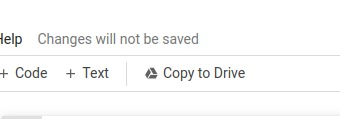

To ensure you can make changes to the notebook save a copy of it to your own drive and work on that one. You can do that by going to "File" -> "Save a copy in Drive".

**Failing to do so will result in code loss!**

 **Note** Make sure you are the only one that has access to it!


# Setup

In [1]:
#@markdown **NOTE**: It is strongly advised you save your results to Google
#@markdown Drive as they will be deleted from Colab once it restarts.
#@markdown To connect Google Drive run this cell, login to your account, and approve all the requested permissions.
from google.colab import drive
drive.mount('/content/gdrive/')

ROOT_GDRIVE_PATH="/content/gdrive/MyDrive/"
GDRIVE_SAVE_REL_PATH = "IMPR_Ex5"
FULL_GDRIVE_SAVE_PATH = ROOT_GDRIVE_PATH + GDRIVE_SAVE_REL_PATH

print(f'Mounted Google Drive, code and results will be saved to the "{GDRIVE_SAVE_REL_PATH}" dir...')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
Mounted Google Drive, code and results will be saved to the "IMPR_Ex5" dir...


In [2]:
#@markdown #Image Processing - 67829. { display-mode: "form" }
#@markdown ##Exercise 5
#@markdown ##Due date: 22.01.2026 at 23:59
#@title{ display-mode: "form" }

#@markdown
#@markdown This exercise is a bit different than the rest of the exercises in the course.
#@markdown The submissions will be a PDF file with your answers and results to the exercise.
#@markdown This notebook provides the basic code, but you do not need to adhere to some specific API
#@markdown and we will not be running unit tests on your code.
#@markdown We will however, be going over your code and running it manually.
#@markdown Moreover, we will be running tests to ensure the authenticity of your solution and detect plagiarism.
#@markdown
#@markdown
#@markdown Before you start working on the exercise it is recommended that you review the lecture slides covering neural networks.
#@markdown
#@markdown
#@markdown **NOTE**: Neural networks are typically trained on GPUs, without GPUs training takes much longer.
#@markdown To enable GPU tranining click on "Runtime" -> "Change runtime type" -> "GPU" -> "SAVE".
#@markdown
#@markdown **NOTE**: A short guide on debugging your code using colab is availble [here](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/01.06-Errors-and-Debugging.ipynb#scrollTo=qnIn-rWFqoww).

#@markdown But first, we have to download all of the dependencies and install them.
#@markdown Play this cell to download it and get everything ready. markdown This may take a few minutes.

# Install dependencies.
!pip install bitsandbytes transformers accelerate peft -q
!pip install git+https://github.com/huggingface/diffusers.git -q
!pip install datasets -q

import os
import locale
import re
import glob
from PIL import Image
from diffusers import DiffusionPipeline
import torch
from diffusers import StableDiffusionImg2ImgPipeline
from diffusers.utils import load_image


locale.getpreferredencoding = lambda: "UTF-8"

!accelerate config default
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py

# Set Hugging Face cache to Google Drive
HF_CACHE_DIR = f"{FULL_GDRIVE_SAVE_PATH}/huggingface_cache"
os.makedirs(HF_CACHE_DIR, exist_ok=True)

# Set environment variables
os.environ['HF_HOME'] = HF_CACHE_DIR
os.environ['HUGGINGFACE_HUB_CACHE'] = HF_CACHE_DIR
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE_DIR

print(f"✅ Hugging Face cache set to: {HF_CACHE_DIR}")


# Updating training script to save validation outputs locally

file_path = 'train_dreambooth_lora.py'

with open(file_path, 'r') as f:
    content = f.read()

# --- 1. Fix the log_validation function to handle 'step' and save to disk ---
# We replace the tracker loop logic to save to disk using the 'epoch' variable
# which we will now treat as the 'step' variable.
old_tracker_block = r'    for tracker in accelerator.trackers:.*?(?=    del pipeline)'
new_tracker_block = '''    # --- DISK SAVING PATCH ---
    if accelerator.is_main_process:
        val_save_dir = os.path.join(args.output_dir, "validation_images")
        os.makedirs(val_save_dir, exist_ok=True)
        label = "final" if is_final_validation else f"step_{epoch}"
        for i, image in enumerate(images):
            image.save(os.path.join(val_save_dir, f"{label}_img_{i}.png"))
        logger.info(f"✅ Saved validation images for {label}")
    # --------------------------
    for tracker in accelerator.trackers:'''

content = re.sub(old_tracker_block, new_tracker_block, content, flags=re.DOTALL)

# --- 2. Move Validation Trigger from Epoch Loop to Step Loop ---
# First, we remove the old validation block that triggers at the end of epochs
epoch_val_pattern = r'        if accelerator\.is_main_process:\n            if args\.validation_prompt is not None and epoch % args\.validation_epochs == 0:.*?log_validation\(.*?weight_dtype=weight_dtype,\n                \)'
content = re.sub(epoch_val_pattern, '', content, flags=re.DOTALL)

# Now, we insert a NEW trigger inside the step loop, right where checkpoints are saved.
# We look for the checkpoint saving logic as our anchor.
checkpoint_anchor = '                        accelerator.save_state(save_path)\n                        logger.info(f"Saved state to {save_path}")'
validation_trigger = '''                        accelerator.save_state(save_path)
                        logger.info(f"Saved state to {save_path}")

                        # --- NEW VALIDATION TRIGGER (Step-based) ---
                        if args.validation_prompt is not None:
                            logger.info(f"Running validation at step {global_step}...")
                            pipeline = DiffusionPipeline.from_pretrained(
                                args.pretrained_model_name_or_path,
                                unet=unwrap_model(unet),
                                text_encoder=None if args.pre_compute_text_embeddings else unwrap_model(text_encoder),
                                revision=args.revision,
                                variant=args.variant,
                                torch_dtype=weight_dtype,
                            )
                            p_args = {"prompt": args.validation_prompt} if not args.pre_compute_text_embeddings else {
                                "prompt_embeds": validation_prompt_encoder_hidden_states,
                                "negative_prompt_embeds": validation_prompt_negative_prompt_embeds,
                            }
                            log_validation(pipeline, args, accelerator, p_args, global_step, weight_dtype)'''

content = content.replace(checkpoint_anchor, validation_trigger)

with open(file_path, 'w') as f:
    f.write(content)



def image_grid(imgs, rows, cols, resize=256):

    if resize is not None:
        imgs = [img.resize((resize, resize)) for img in imgs]
    w, h = imgs[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Configuration already exists at /root/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.
--2026-01-31 22:56:22--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 59191 (58K) [text/plain]
Saving to: ‘train_dreambooth_lora.py.9’

train_dreambooth_lo 100%[===================>]  57.80K  --.-KB/s    in 0.001s  

2026-01-31 22:56:22 (53.1 MB/s) - ‘train_dreambooth_lora.py.9’ saved [59191/59191]

✅ Hugging Face cache set to: /content/gdrive/MyDrive/IMPR_Ex5/huggingface_cache


# Dataset loading

Saving WhatsApp Image 2026-01-16 at 11.21.45 (1).jpeg to WhatsApp Image 2026-01-16 at 11.21.45 (1).jpeg
Saving WhatsApp Image 2026-01-16 at 11.21.45.jpeg to WhatsApp Image 2026-01-16 at 11.21.45.jpeg


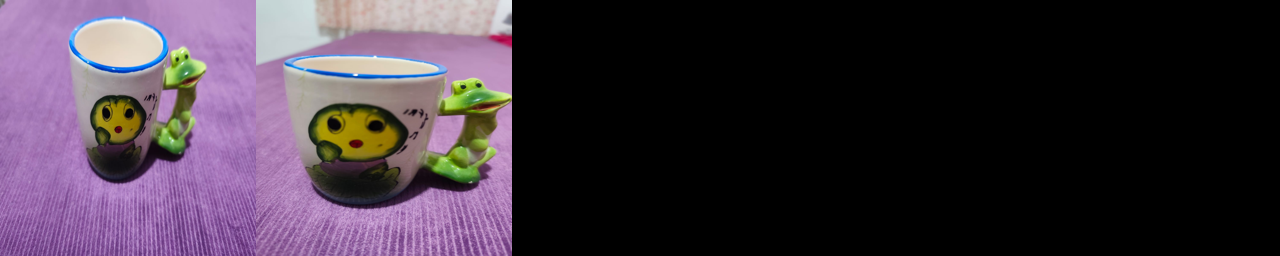

In [ ]:
#@markdown Upload your dataset.
#@markdown
#@markdown **NOTE**: For sanity check you can call the next cell instead and use an example dataset.
import os
from google.colab import files

# pick a name for the image folder
dataset_dir_name = "dataset_bad" #@param
dataset_dir = f"{FULL_GDRIVE_SAVE_PATH}/dreambooth_datasets/{dataset_dir_name}"
os.makedirs(dataset_dir, exist_ok=True)
os.chdir(dataset_dir)

# choose and upload local images into the newly created directory
uploaded_images = files.upload()
os.chdir("/content") # back to parent directory


# Display 5 images
extensions = ['*.png', '*.jpg', '*.jpeg', '*.JPG', '*.PNG']
imgs_paths = []

for ext in extensions:
    imgs_paths.extend(glob.glob(f"{dataset_dir}/{ext}"))

# Sort them to keep the order consistent
imgs_paths.sort()

imgs = [Image.open(path) for path in imgs_paths]

num_imgs_to_preview = 5
image_grid(imgs[:num_imgs_to_preview], 1, num_imgs_to_preview)

In [ ]:
#@markdown Example dataset for sanity testing
#@markdown
#@markdown **NOTE**: For sanity check you can call the next cell instead and use an example dataset.

from huggingface_hub import snapshot_download


dataset_dir = f"{FULL_GDRIVE_SAVE_PATH}/dreambooth_datasets/example_dog"
os.makedirs(dataset_dir, exist_ok=True)

snapshot_download("diffusers/dog-example", local_dir=dataset_dir, repo_type="dataset", ignore_patterns=".gitattributes",)


# Display 5 images
extensions = ['*.png', '*.jpg', '*.jpeg', '*.JPG', '*.PNG']
imgs_paths = []

for ext in extensions:
    imgs_paths.extend(glob.glob(f"{dataset_dir}/{ext}"))

# Sort them to keep the order consistent
imgs_paths.sort()

imgs = [Image.open(path) for path in imgs_paths]

num_imgs_to_preview = 5
image_grid(imgs[:num_imgs_to_preview], 1, num_imgs_to_preview)

# Training DreamBooth

Below is an example of a how to run a training session of DreamBooth.
Important parameters:

- `instance_prompt` - used to describe the training dataset and the unique text token to personalize the concept to (in our case `TOK`).
- `validation_prompt` - used for generating validation images of this prompt during training (need to use the unique token in the prompt).
- `output_dir` - Path to save the results (checkpoints and validation images)
- `max_train_steps` - Number of training steps.
- `checkpointing_steps` - How often to save checkpoints of the model
- `validation_epochs` - How often to run the validation

For more training arguments and training details, see the original training script [here](https://github.com/huggingface/diffusers/blob/main/examples/dreambooth/train_dreambooth_lora.py), and read about it [here](https://github.com/huggingface/diffusers/blob/main/examples/dreambooth/README.md) and [here](https://huggingface.co/docs/diffusers/en/training/dreambooth).

**Note:** Training for 1000 steps can take 15-30 minutes.

In [ ]:
!accelerate launch train_dreambooth_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5"  \
  --instance_data_dir="/content/gdrive/MyDrive/IMPR_Ex5/dreambooth_datasets/dataset_bad" \
  --output_dir="$FULL_GDRIVE_SAVE_PATH/my_cup_outputs_bad" \
  --instance_prompt="a photo of a cup with frog" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --checkpointing_steps=50 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=500 \
  --validation_prompt="a photo of a cup with frog on a snowy mountain" \
  --validation_epochs=50 \
  --seed="0" \
  --num_validation_images=4

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2026-01-24 20:44:10.887735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already bee

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Generating Images from Trained DreamBooth

In [ ]:
# Load the trained model
import torch
from diffusers import DiffusionPipeline
pipe = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5").to("cuda")

lora_checkpoint_path = "/content/gdrive/MyDrive/IMPR_Ex5/my_cup_outputs_1/pytorch_lora_weights.safetensors"
pipe.load_lora_weights(lora_checkpoint_path)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

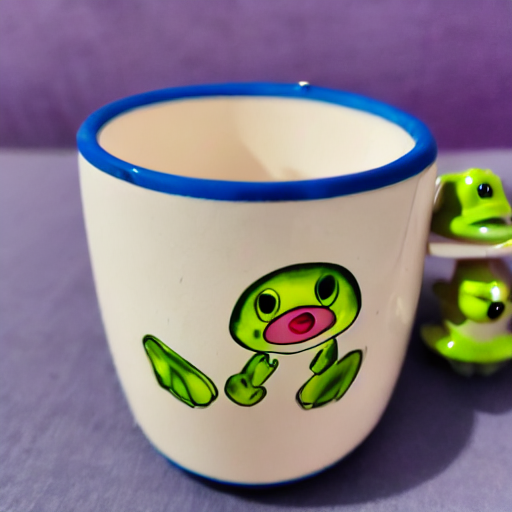

In [ ]:
# Generate an image
prompt = "a photo of a cup with frog on the moon"
image = pipe(prompt=prompt, num_inference_steps=50).images[0]
display(image)

# Running SDEdit

**Note: If you are getting an `OutOfMemoryError: CUDA out of memory...` error you may need to remove some of the StableDiffusion pipelines from you memory or restart the notebook to get a fresh GPU memory.**

🚀 Loading base SDEdit pipeline...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

🎨 Loading LoRA-tuned SDEdit pipeline...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

⏳ Running SDEdit on Original Model...


  0%|          | 0/25 [00:00<?, ?it/s]

⏳ Running SDEdit on LoRA Model...


  0%|          | 0/25 [00:00<?, ?it/s]


Results Order: [Input Image] | [Original Model SDEdit] | [LoRA Model SDEdit]


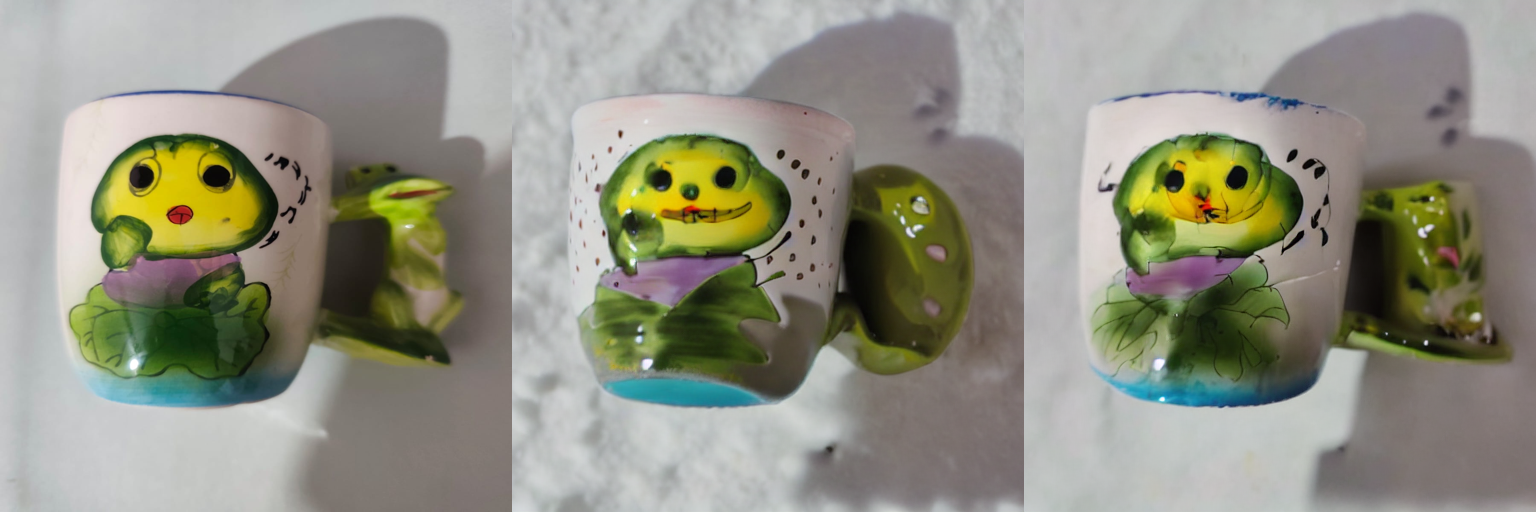

In [3]:
lora_weights_path = "/content/gdrive/MyDrive/IMPR_Ex5/my_cup_outputs/pytorch_lora_weights.safetensors"
image_to_edit_path = "/content/gdrive/MyDrive/IMPR_Ex5/dreambooth_datasets/dataset/image1.jpeg"
init_image = load_image(image_to_edit_path).convert("RGB").resize((512, 512))

prompt = "A ceramic cup on a snow"
strength = 0.5  # This is the SDEdit 'faithfulness' parameter (0.0 = no change, 1.0 = full redraw)
num_inference_steps = 50
seed = 42

# LOAD ORIGINAL PIPELINE
print("🚀 Loading base SDEdit pipeline...")
base_pipe = StableDiffusionImg2ImgPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5").to("cuda")

# LOAD LORA PIPELINE
print("🎨 Loading LoRA-tuned SDEdit pipeline...")
lora_pipe = StableDiffusionImg2ImgPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5").to("cuda")
lora_pipe.load_lora_weights(lora_weights_path, weight_name="pytorch_lora_weights.safetensors")


# RUN INFERENCE (SDEdit) Original
generator = torch.Generator("cuda").manual_seed(seed) # Reset random seed generator for consistency, this ensures the generation uses the same seeds
print("⏳ Running SDEdit on Original Model...")
image_original = base_pipe(prompt=prompt, image=init_image, strength=strength, num_inference_steps=num_inference_steps, generator=generator).images[0]

# RUN INFERENCE (SDEdit) DreamBooth
generator = torch.Generator("cuda").manual_seed(seed) # Reset random seed generator for consistency, this ensures the generation uses the same seeds
print("⏳ Running SDEdit on LoRA Model...")
image_lora = lora_pipe(prompt=prompt, image=init_image, strength=strength, num_inference_steps=num_inference_steps, generator=generator).images[0]


# DISPLAY RESULTS
comparison = Image.new('RGB', (1536, 512))
comparison.paste(init_image, (0, 0))
comparison.paste(image_original, (512, 0))
comparison.paste(image_lora, (1024, 0))

print("\nResults Order: [Input Image] | [Original Model SDEdit] | [LoRA Model SDEdit]")
display(comparison)

# Forensics Challenge (Membership Inference)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


a.png: 0.097182
b.png: 0.076209
c.png: 0.104448
d.png: 0.087491
e.png: 0.073350
f.png: 0.070873

--- סיכום תוצאות ---
1. f.png: 0.070873 -> Train (Likely)
2. e.png: 0.073350 -> Train (Likely)
3. b.png: 0.076209 -> Train (Likely)
4. d.png: 0.087491 -> Test (Likely)
5. a.png: 0.097182 -> Test (Likely)
6. c.png: 0.104448 -> Test (Likely)


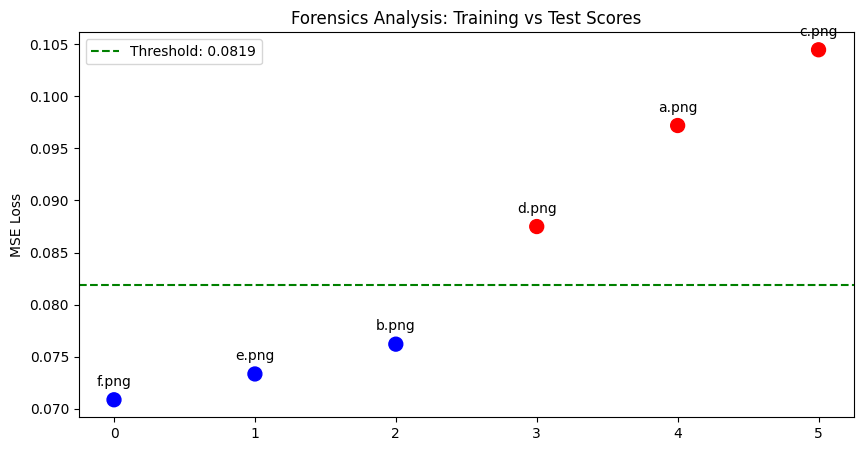

In [3]:
import torch
import torch.nn.functional as F
import os
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline
from google.colab import drive

drive.mount('/content/gdrive')

BASE_PATH = "/content/gdrive/MyDrive/IMPR_Ex5/ex5_forensics_supplementary/ex5_forensics_supplementary"
LORA_PATH = os.path.join(BASE_PATH, "checkpoint-1500")
image_names = ["a.png", "b.png", "c.png", "d.png", "e.png", "f.png"]


def get_membership_score(image, pipe, unique_token="TOK", class_name="person", timestep=500):
    img_tensor = pipe.image_processor.preprocess(image).to(device="cuda", dtype=torch.float16)

    with torch.no_grad():
        latents = pipe.vae.encode(img_tensor).latent_dist.sample()
        latents = latents * pipe.vae.config.scaling_factor

    generator = torch.Generator(device="cuda").manual_seed(42)

    noise = torch.randn(
        latents.size(),
        generator=generator,
        device="cuda",
        dtype=torch.float16
    )

    t = torch.tensor([timestep], device="cuda")

    noisy_latents = pipe.scheduler.add_noise(latents, noise, t)
    prompt = f"a photo of {unique_token} {class_name}"

    with torch.no_grad():
        encoder_hidden_states = pipe.encode_prompt(prompt, "cuda", 1, False)[0]
        noise_pred = pipe.unet(
            noisy_latents,
            t,
            encoder_hidden_states.to(dtype=torch.float16)
        ).sample

    loss = F.mse_loss(noise_pred.float(), noise.float(), reduction="mean")
    return loss.item()
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to("cuda")

pipe.load_lora_weights(LORA_PATH)

results = {}

for name in image_names:
    img_path = os.path.join(BASE_PATH, name)
    if os.path.exists(img_path):
        img = Image.open(img_path).convert("RGB")
        score = get_membership_score(img, pipe)
        results[name] = score
        print(f"{name}: {score:.6f}")


sorted_results = sorted(results.items(), key=lambda x: x[1])

print("\n--- סיכום תוצאות ---")
for i, (name, score) in enumerate(sorted_results):
    category = "Train (Likely)" if i < 3 else "Test (Likely)"
    print(f"{i+1}. {name}: {score:.6f} -> {category}")

threshold = (sorted_results[2][1] + sorted_results[3][1]) / 2

scores_plot = [r[1] for r in sorted_results]
plt.figure(figsize=(10, 5))
plt.scatter(range(len(scores_plot)), scores_plot, c=['blue']*3 + ['red']*3, s=100)
plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold: {threshold:.4f}')
for i, (name, _) in enumerate(sorted_results):
    plt.annotate(name, (i, scores_plot[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.title("Forensics Analysis: Training vs Test Scores")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()